Saving GaGS7dcb0AAz6Rw.jpg to GaGS7dcb0AAz6Rw.jpg


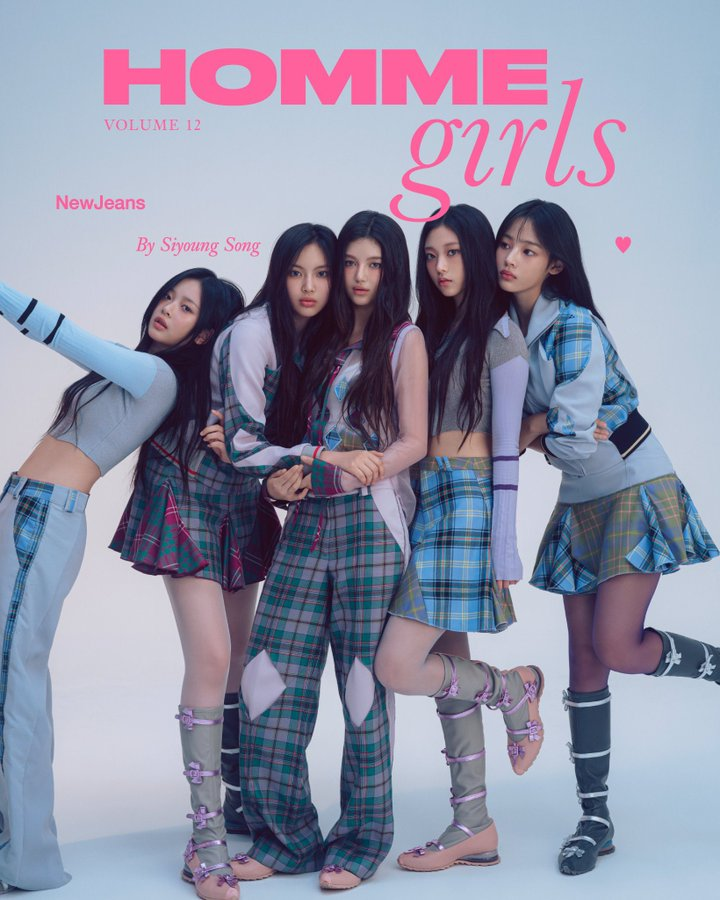

In [3]:
from google.colab import files
from google.colab.patches import cv2_imshow
import numpy as np
import cv2

# Tai anh len tu may tinh
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
img = cv2.imread(img_name)

# Hien thi anh
cv2_imshow(img)

In [5]:
img.shape

(900, 720, 3)

In [6]:
gamma = 1.5

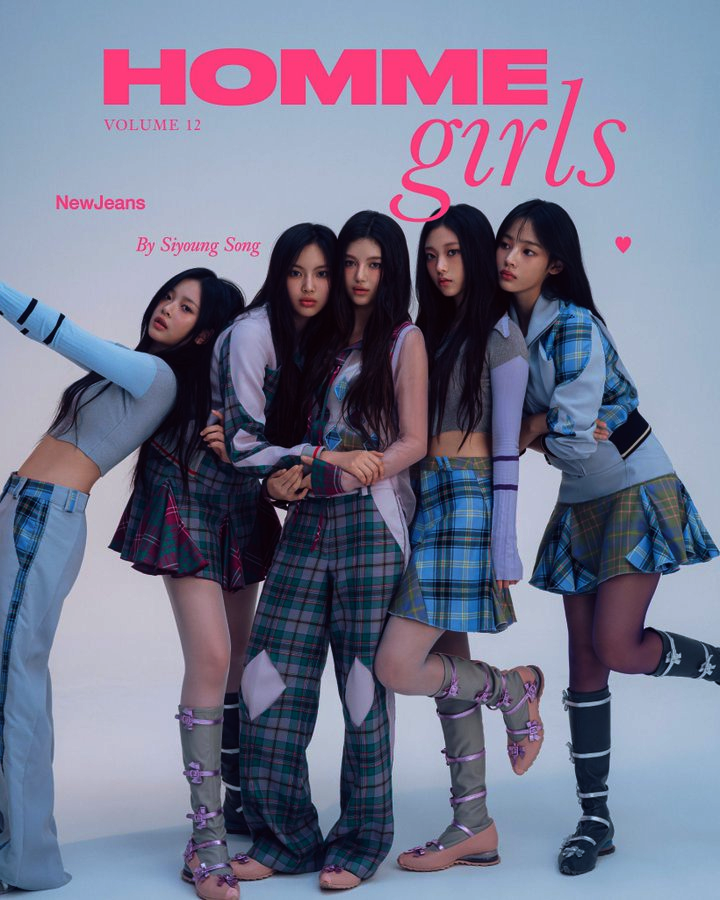

In [8]:
gamma_corrected = np . power ( img / 255.0 , gamma ) * 255.0
gamma_corrected = np . uint8 ( gamma_corrected )
cv2_imshow ( gamma_corrected )


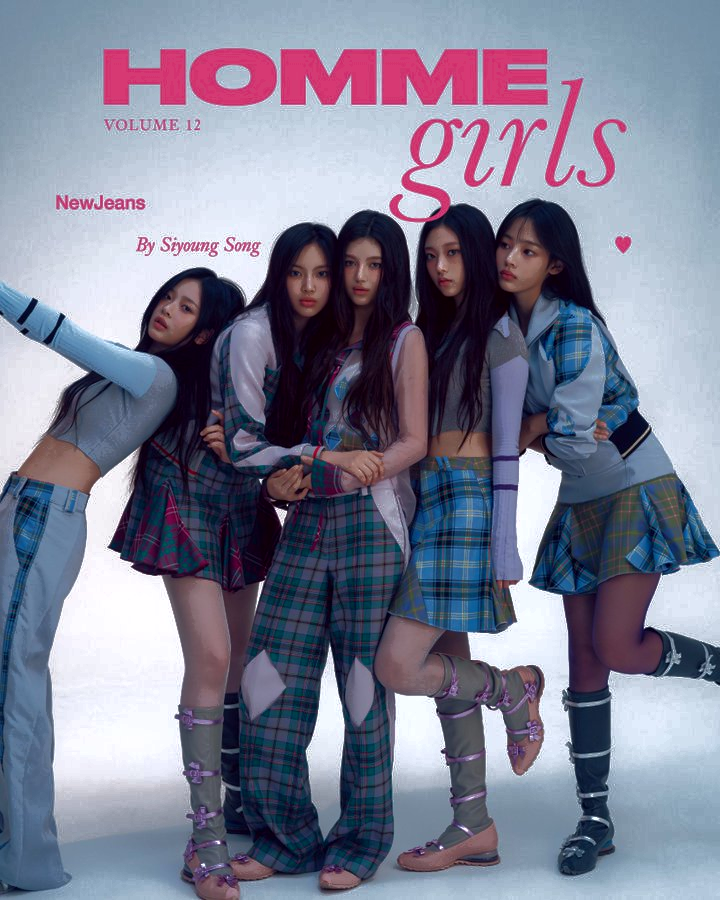

In [9]:
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
# 3. Cân bằng histogram chỉ trên kênh độ sáng (Y channel)
# Kênh Y chứa thông tin độ sáng, còn U và V chứa thông tin màu sắc
img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])

# 4. Chuyển đổi ảnh từ không gian màu YUV trở lại BGR để hiển thị
equalized = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

cv2_imshow(equalized)

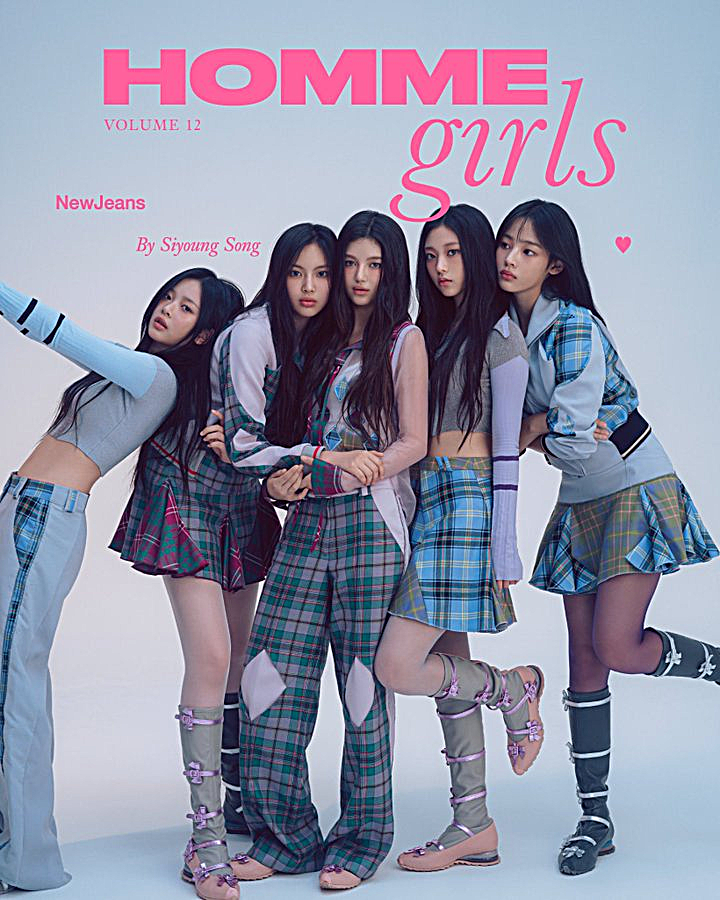

In [11]:
gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
unsharp = cv2.addWeighted(img, 2.0, gaussian, -1.0, 0)
cv2_imshow(unsharp)


In [12]:
# Bài 2: Truy cập Camera và Thao tác (Thực hiện ở máy local)

In [1]:
import cv2

cap = cv2.VideoCapture(0)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

if not face_cascade.load(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'):
    print("Error loading face cascade")
    exit()

while True:
    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    cv2.imshow('Original', frame)
    cv2.imshow('Edges', edges)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()